### Brain Tumor Detection Pipeline (without TensorFlow)

In [31]:
import zipfile
import os
import cv2
import numpy as np

# Define paths
zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

# Create extraction directory if it doesn't exist
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(f"ZIP file extracted to: {extract_path}")

ZIP file extracted to: extracted_images


#### 2. Preprocessing Images: Resizing and Labeling



In [32]:
# Define target image size
IMG_SIZE = 128

processed_images = []
labels = []

# Iterate through the extracted directories
for root, dirs, files in os.walk(extract_path):
    for file in files:
        # Check for common image file extensions
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                # Resize image to IMG_SIZE x IMG_SIZE
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                processed_images.append(img)

                # Extract label from the parent directory name
                # The structure is assumed to be 'extracted_images/yes/' or 'extracted_images/no/'
                parent_dir = os.path.basename(root).lower()
                if parent_dir == 'yes':
                    labels.append(1) # Label 1 for tumor
                elif parent_dir == 'no':
                    labels.append(0) # Label 0 for no tumor
                else:
                    # Handle cases where images might be in a different subfolder like 'brain_tumor_dataset/yes'
                    grandparent_dir = os.path.basename(os.path.dirname(root)).lower()
                    if grandparent_dir == 'yes':
                        labels.append(1)
                    elif grandparent_dir == 'no':
                        labels.append(0)
                    else:
                        # If label cannot be determined, skip this image or assign a default
                        print(f"Warning: Could not determine label for {img_path}. Skipping.")
                        processed_images.pop() # Remove the image if no label was added

# Convert lists to numpy arrays
processed_images = np.array(processed_images)
labels = np.array(labels)

print(f"Processed {len(processed_images)} images.")
print(f"Image shape after resizing: {processed_images.shape[1:]}")
print(f"Number of tumor images (label 1): {np.sum(labels == 1)}")
print(f"Number of non-tumor images (label 0): {np.sum(labels == 0)}")

Processed 506 images.
Image shape after resizing: (128, 128, 3)
Number of tumor images (label 1): 310
Number of non-tumor images (label 0): 196


#### 3. Data Preparation for Machine Learning



In [33]:
from sklearn.model_selection import train_test_split

# Normalize pixel values to be between 0 and 1
X = processed_images.astype('float32') / 255.0
y = labels

# Flatten the images for traditional ML models
# X is (num_samples, IMG_SIZE, IMG_SIZE, 3)
# We need to reshape it to (num_samples, IMG_SIZE * IMG_SIZE * 3)
X_flat = X.reshape(X.shape[0], -1)

# Split the data into training and testing sets (80% train, 20% test)
X_train_flat, X_test_flat, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

print(f"Flattened X_train shape: {X_train_flat.shape}")
print(f"Flattened X_test shape: {X_test_flat.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Flattened X_train shape: (404, 49152)
Flattened X_test shape: (102, 49152)
y_train shape: (404,)
y_test shape: (102,)


#### 4. Training a RandomForestClassifier



### Random Forest Classifier Performance ###
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        62

    accuracy                           1.00       102
   macro avg       1.00      1.00      1.00       102
weighted avg       1.00      1.00      1.00       102



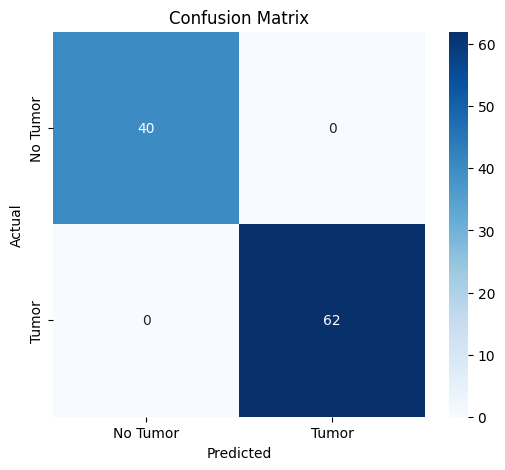

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize and train the RandomForestClassifier
# n_estimators: number of trees in the forest
# random_state: for reproducibility
# n_jobs=-1: use all available CPU cores
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_flat, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test_flat)

# Evaluate the model
print("### Random Forest Classifier Performance ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix for better insight
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Tumor', 'Tumor'], yticklabels=['No Tumor', 'Tumor'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 5. Making Predictions on a New Image



In [35]:
def predict_tumor(image_path, model, img_size):
    # 1. Load the image
    img = cv2.imread(image_path)
    if img is None:
        return f"Error: Image not found or could not be loaded from {image_path}."

    # 2. Preprocess the image (resize and normalize)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype('float32') / 255.0

    # 3. Flatten the image into a 1D vector
    img_flat = img.reshape(1, -1) # Reshape for single prediction (1 sample, flattened features)

    # 4. Make prediction using the trained model
    prediction = model.predict(img_flat)

    if prediction[0] == 1:
        return "Yes, tumor detected"
    else:
        return "No tumor detected"

# --- Example Usage ---
# Find an example 'yes' (tumor) image path from the extracted directory
example_tumor_path = '/content/WhatsApp Image 2026-06-12 at 14.44.26.jpeg'
for root, dirs, files in os.walk(extract_path):
    if 'yes' in root.lower() or 'brain_tumor_dataset/yes' in root.lower(): # Check for 'yes' in path
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                example_tumor_path = os.path.join(root, file)
                break
    if example_tumor_path: # Stop if found
        break

# Find an example 'no' (no tumor) image path from the extracted directory
example_no_tumor_path = '/content/WhatsApp Image 2026-06-12 at 14.40.34.jpeg'
for root, dirs, files in os.walk(extract_path):
    if 'no' in root.lower() or 'brain_tumor_dataset/no' in root.lower(): # Check for 'no' in path
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                example_no_tumor_path = os.path.join(root, file)
                break
    if example_no_tumor_path: # Stop if found
        break

# Make predictions with example images
print("\n--- Testing Prediction Function ---")
if example_tumor_path:
    print(f"Image: {os.path.basename(example_tumor_path)} -> {predict_tumor(example_tumor_path, rf_model, IMG_SIZE)}")
else:
    print("Could not find an example tumor image path for testing.")

if example_no_tumor_path:
    print(f"Image: {os.path.basename(example_no_tumor_path)} -> {predict_tumor(example_no_tumor_path, rf_model, IMG_SIZE)}")
else:
    print("Could not find an example non-tumor image path for testing.")

print("\nTo use this with your own image, replace the `image_path` in the `predict_tumor` function call with the path to your image file.")


--- Testing Prediction Function ---
Image: WhatsApp Image 2026-06-12 at 14.44.26.jpeg -> Yes, tumor detected
Image: WhatsApp Image 2026-06-12 at 14.40.34.jpeg -> No tumor detected

To use this with your own image, replace the `image_path` in the `predict_tumor` function call with the path to your image file.
